# Summary Visualizations

Static manuscript-ready performance charts sourced from the final README comparison tables.


## Setup


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROPOSED_COLOR = "#2ca02c"
BASELINE_COLORS = ["#7f7f7f", "#1f77b4", "#ff7f0e", "#9467bd", "#8c564b"]
ATC_CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def annotate_bars(ax, fmt="{:.2f}", rotation=0, orientation="vertical"):
    for container in ax.containers:
        labels = [
            fmt.format(bar.get_width() if orientation == "horizontal" else bar.get_height())
            for bar in container
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8,
            rotation=rotation,
            color="white",
            fontweight="bold",
        )


## PharmaSales Daily RMSE


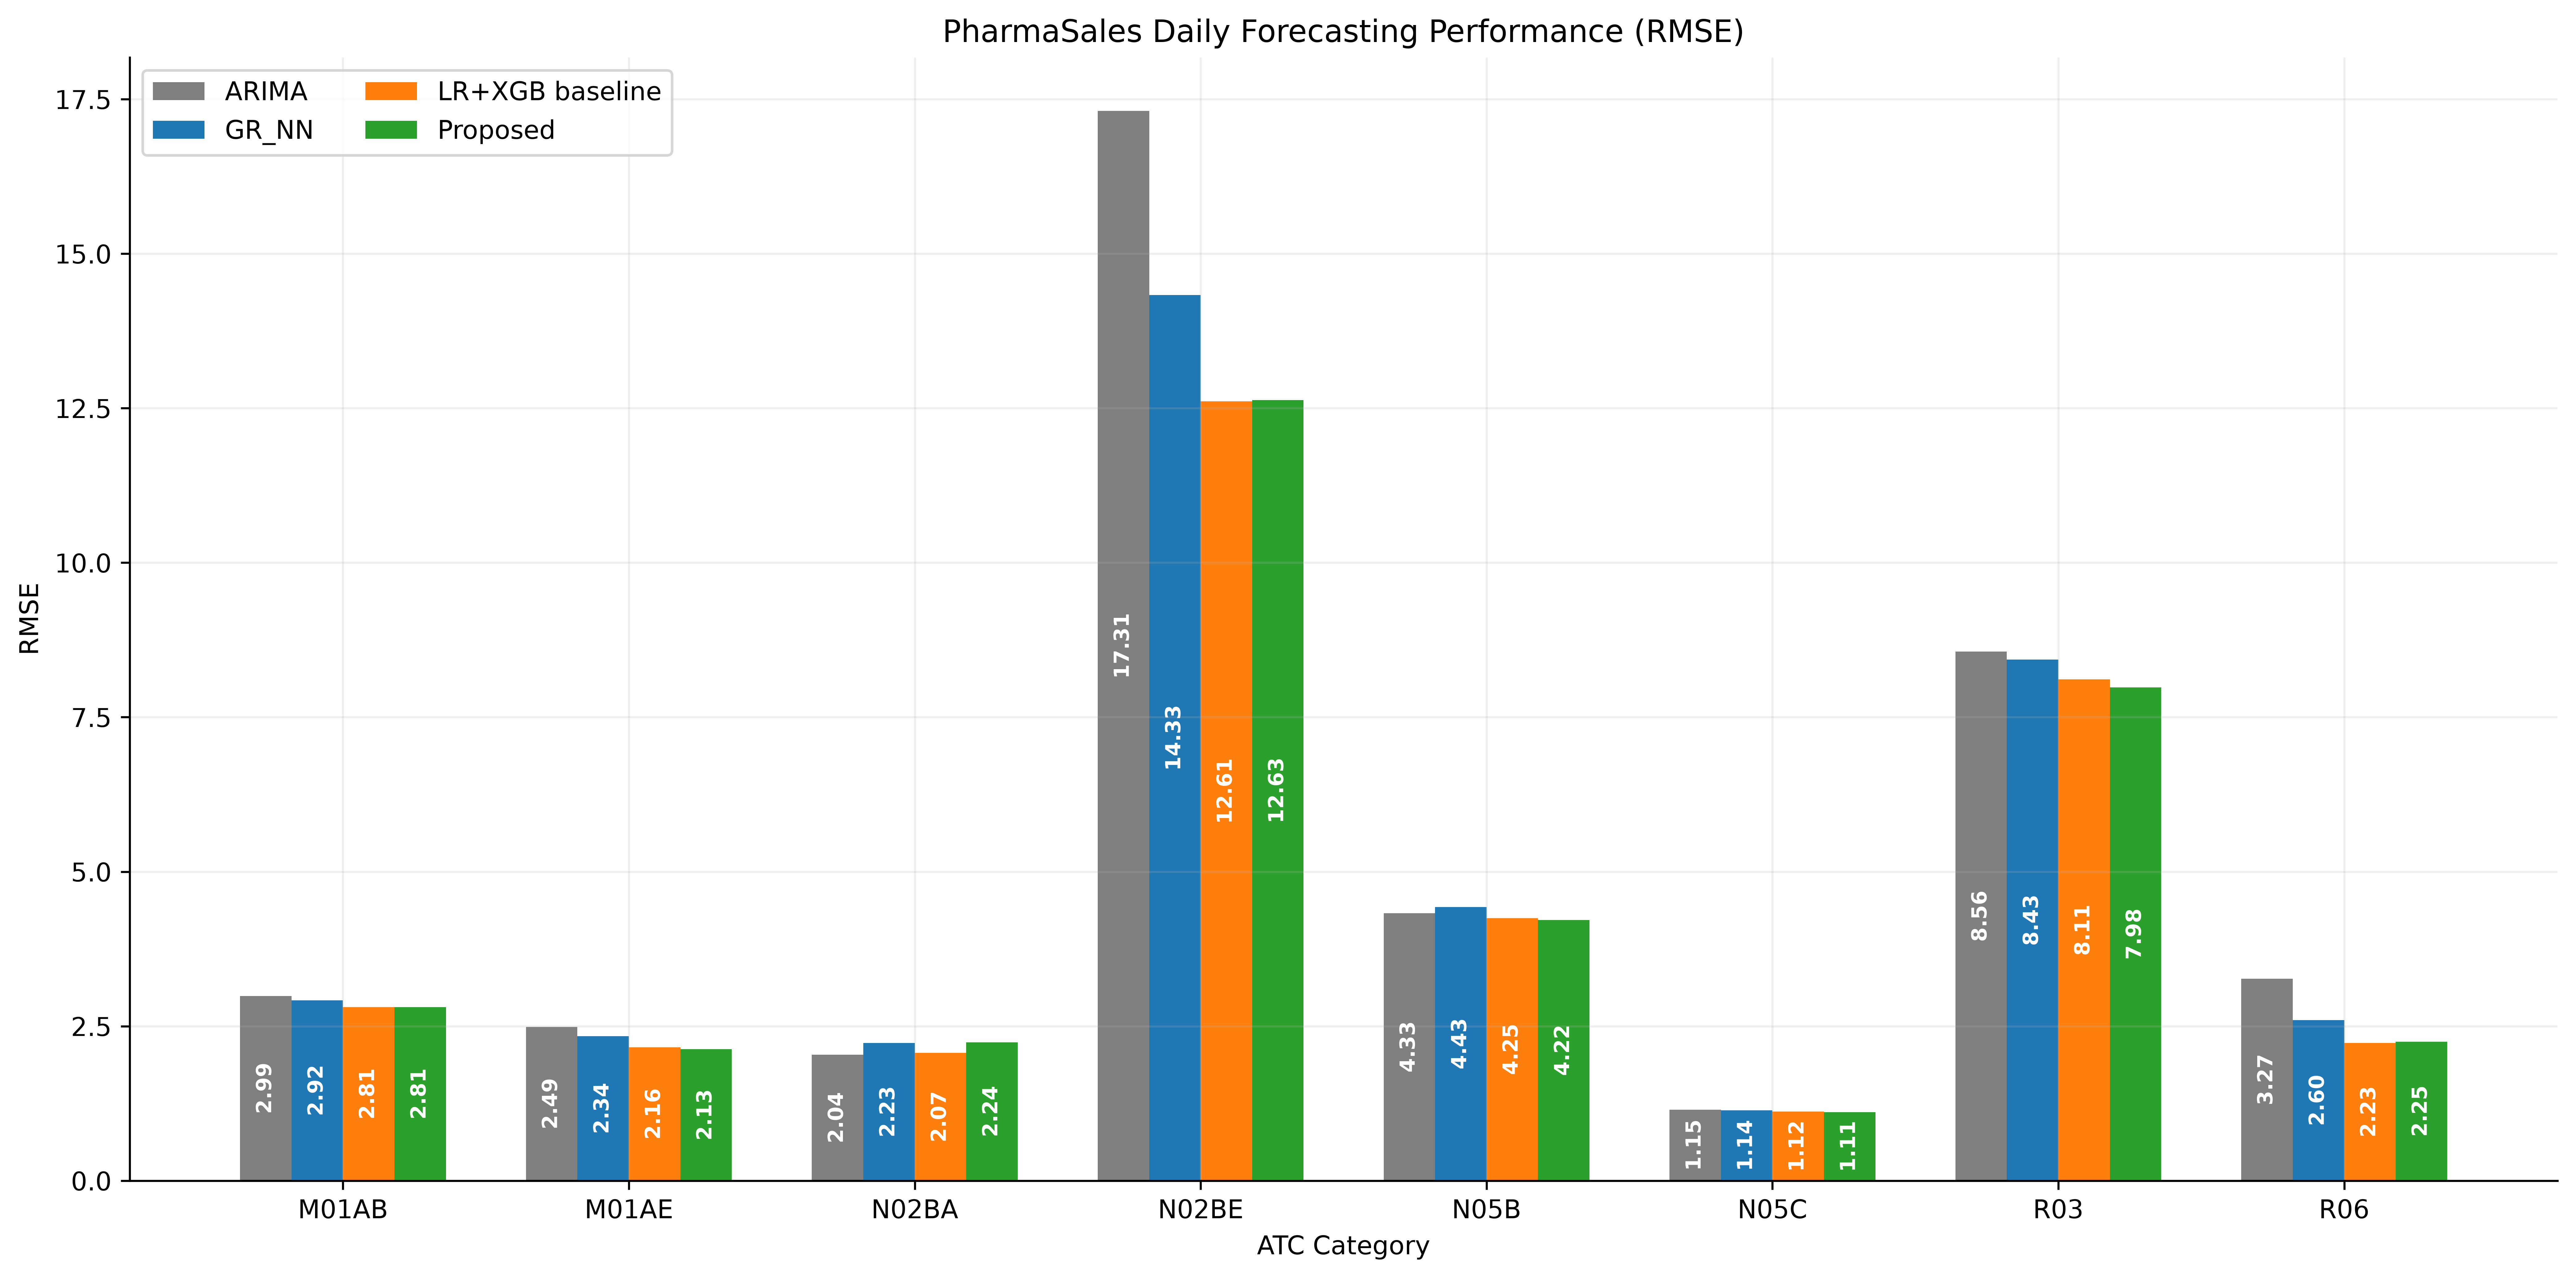

In [22]:
daily_rmse = pd.DataFrame({
    "Category": ATC_CATEGORIES,
    "ARIMA": [2.99, 2.49, 2.04, 17.31, 4.33, 1.15, 8.56, 3.27],
    "GR_NN": [2.92, 2.34, 2.23, 14.33, 4.43, 1.14, 8.43, 2.60],
    "LR+XGB baseline": [2.81, 2.16, 2.07, 12.61, 4.25, 1.12, 8.11, 2.23],
    "Proposed": [2.81, 2.13, 2.24, 12.63, 4.22, 1.11, 7.98, 2.25],
})

models = ["ARIMA", "GR_NN", "LR+XGB baseline", "Proposed"]
x = np.arange(len(ATC_CATEGORIES))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7), dpi=600)
for idx, model in enumerate(models):
    color = PROPOSED_COLOR if model == "Proposed" else BASELINE_COLORS[idx]
    ax.bar(x + (idx - 1.5) * width, daily_rmse[model], width, label=model, color=color)

ax.set_title("PharmaSales Daily Forecasting Performance (RMSE)")
ax.set_xlabel("ATC Category")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(ATC_CATEGORIES)
ax.legend(loc="upper left", ncols=2)
annotate_bars(ax, fmt="{:.2f}", rotation=90)
plt.tight_layout()
plt.show()


## PharmaSales Weekly MSE


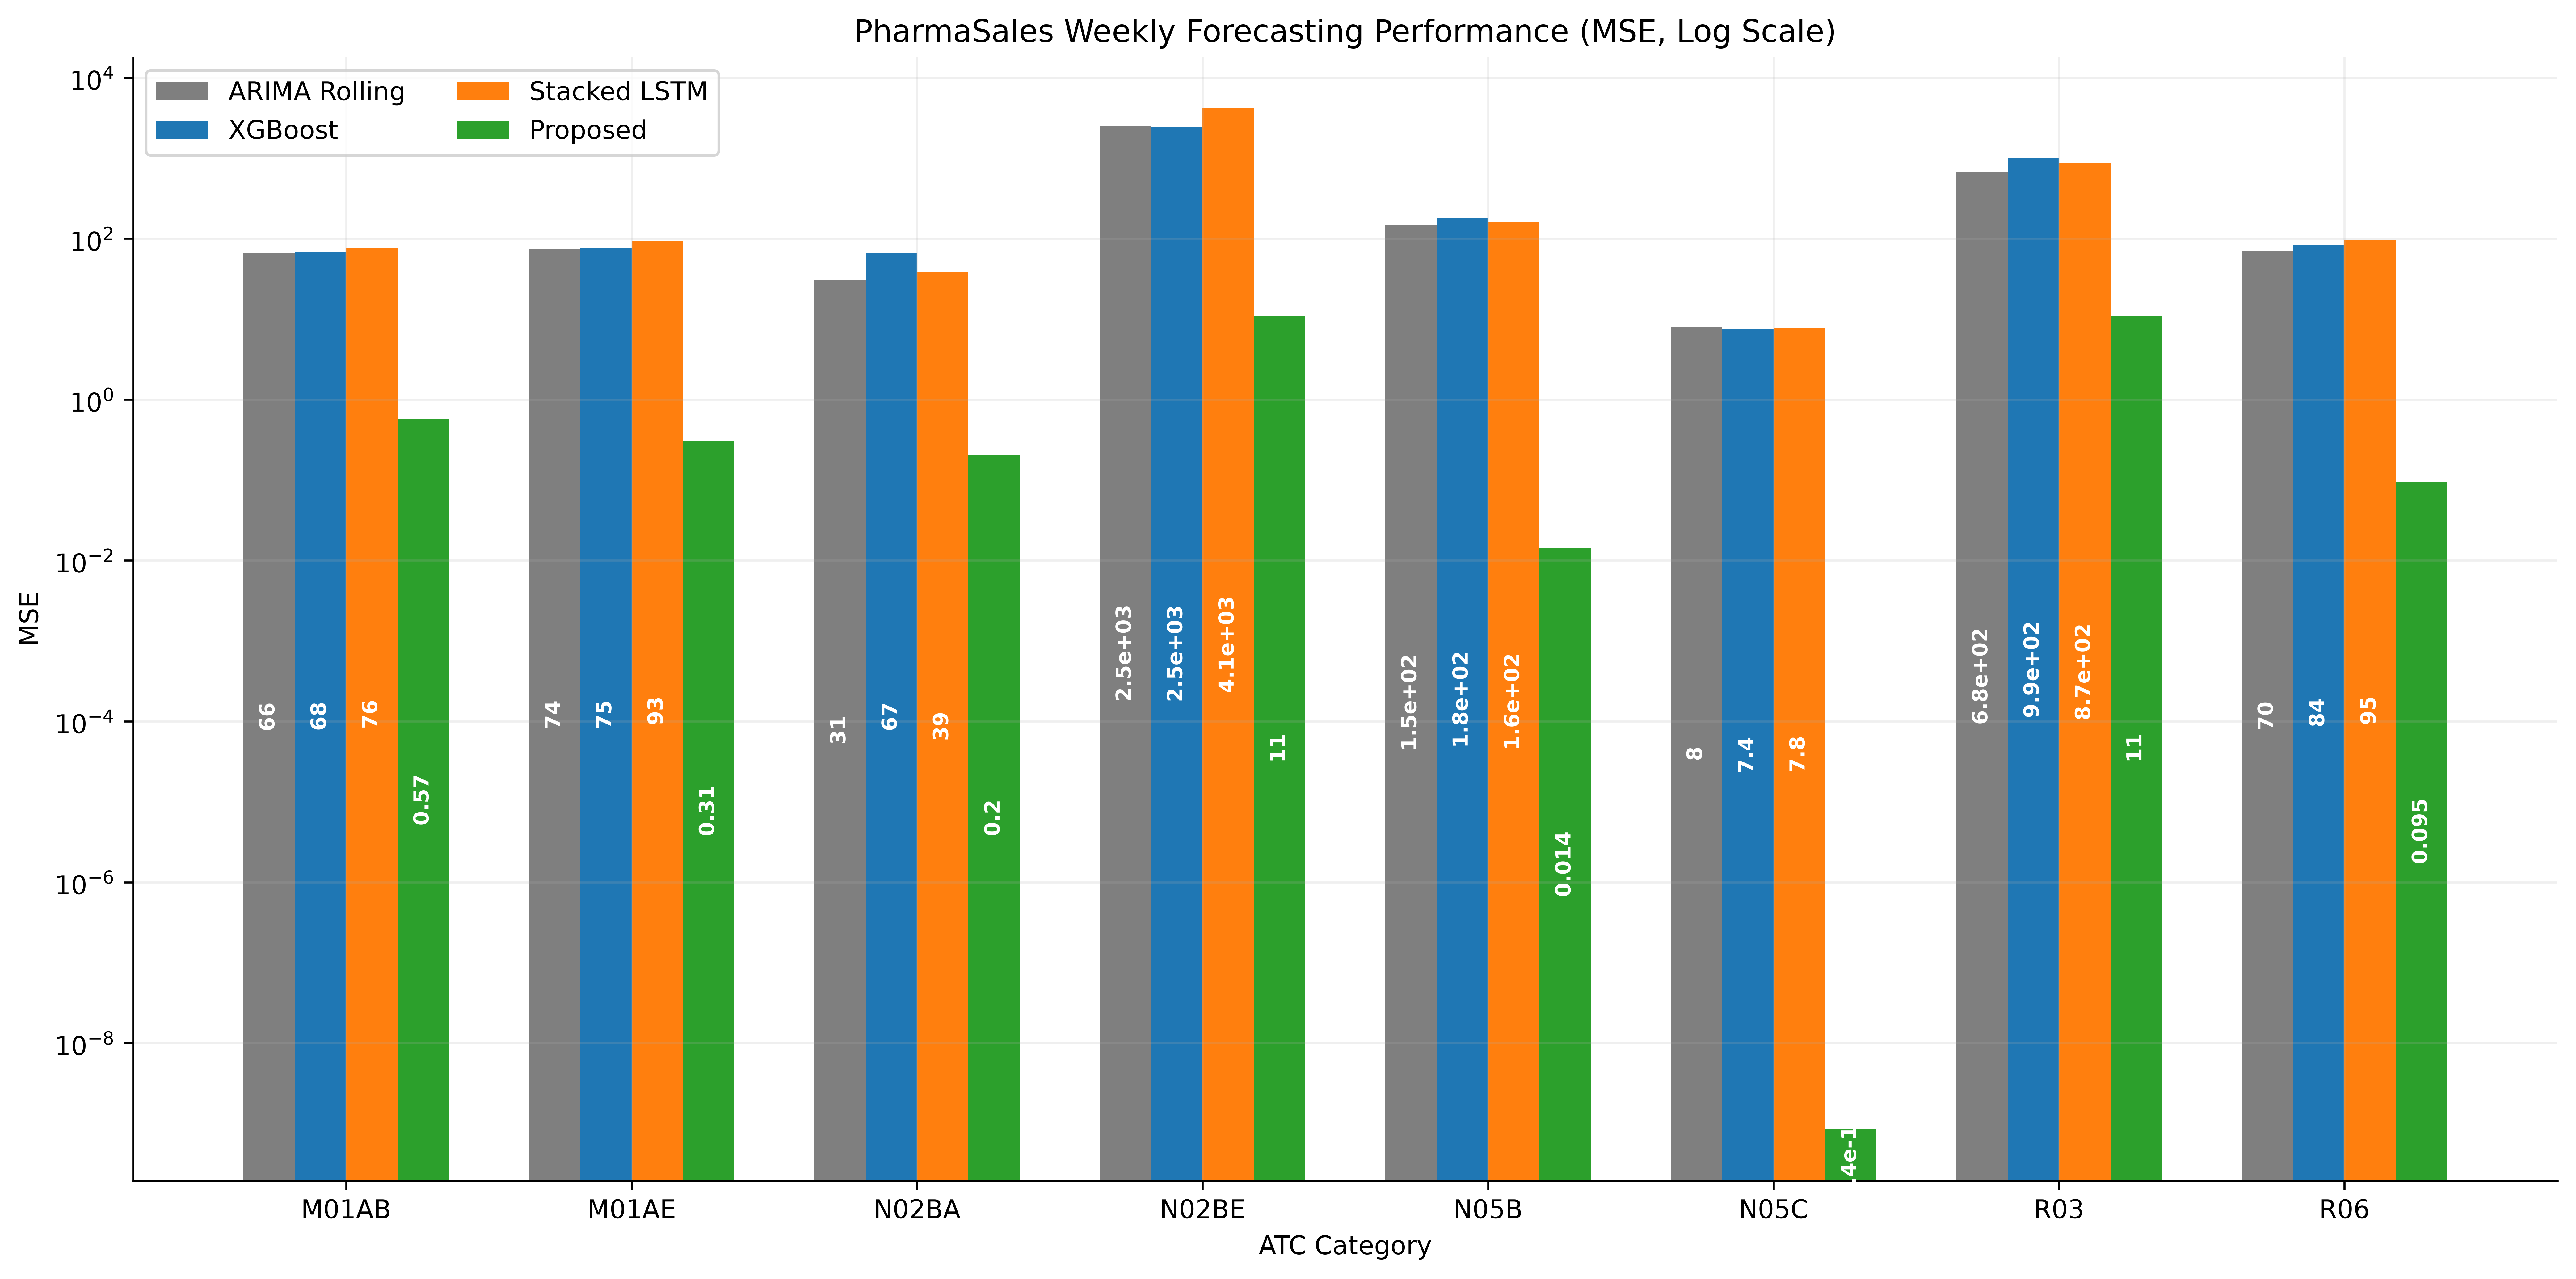

In [23]:
weekly_mse = pd.DataFrame({
    "Category": ATC_CATEGORIES,
    "ARIMA Rolling": [66.08, 74.14, 30.97, 2525.41, 149.74, 7.99, 677.92, 70.25],
    "XGBoost": [68.22, 75.45, 66.88, 2470.51, 178.77, 7.44, 993.66, 83.97],
    "Stacked LSTM": [76.29, 93.25, 38.54, 4145.11, 158.71, 7.77, 866.70, 94.91],
    "Proposed": [0.5735, 0.3079, 0.2032, 10.9702, 0.0144, 8.41e-10, 11.0293, 0.0945],
})

models = ["ARIMA Rolling", "XGBoost", "Stacked LSTM", "Proposed"]
x = np.arange(len(ATC_CATEGORIES))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7), dpi=600)
for idx, model in enumerate(models):
    color = PROPOSED_COLOR if model == "Proposed" else BASELINE_COLORS[idx]
    ax.bar(x + (idx - 1.5) * width, weekly_mse[model], width, label=model, color=color)

ax.set_title("PharmaSales Weekly Forecasting Performance (MSE, Log Scale)")
ax.set_xlabel("ATC Category")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(ATC_CATEGORIES)
ax.legend(loc="upper left", ncols=2)
annotate_bars(ax, fmt="{:.2g}", rotation=90)
plt.tight_layout()
plt.show()


## Rossmann Original Scale RMSE


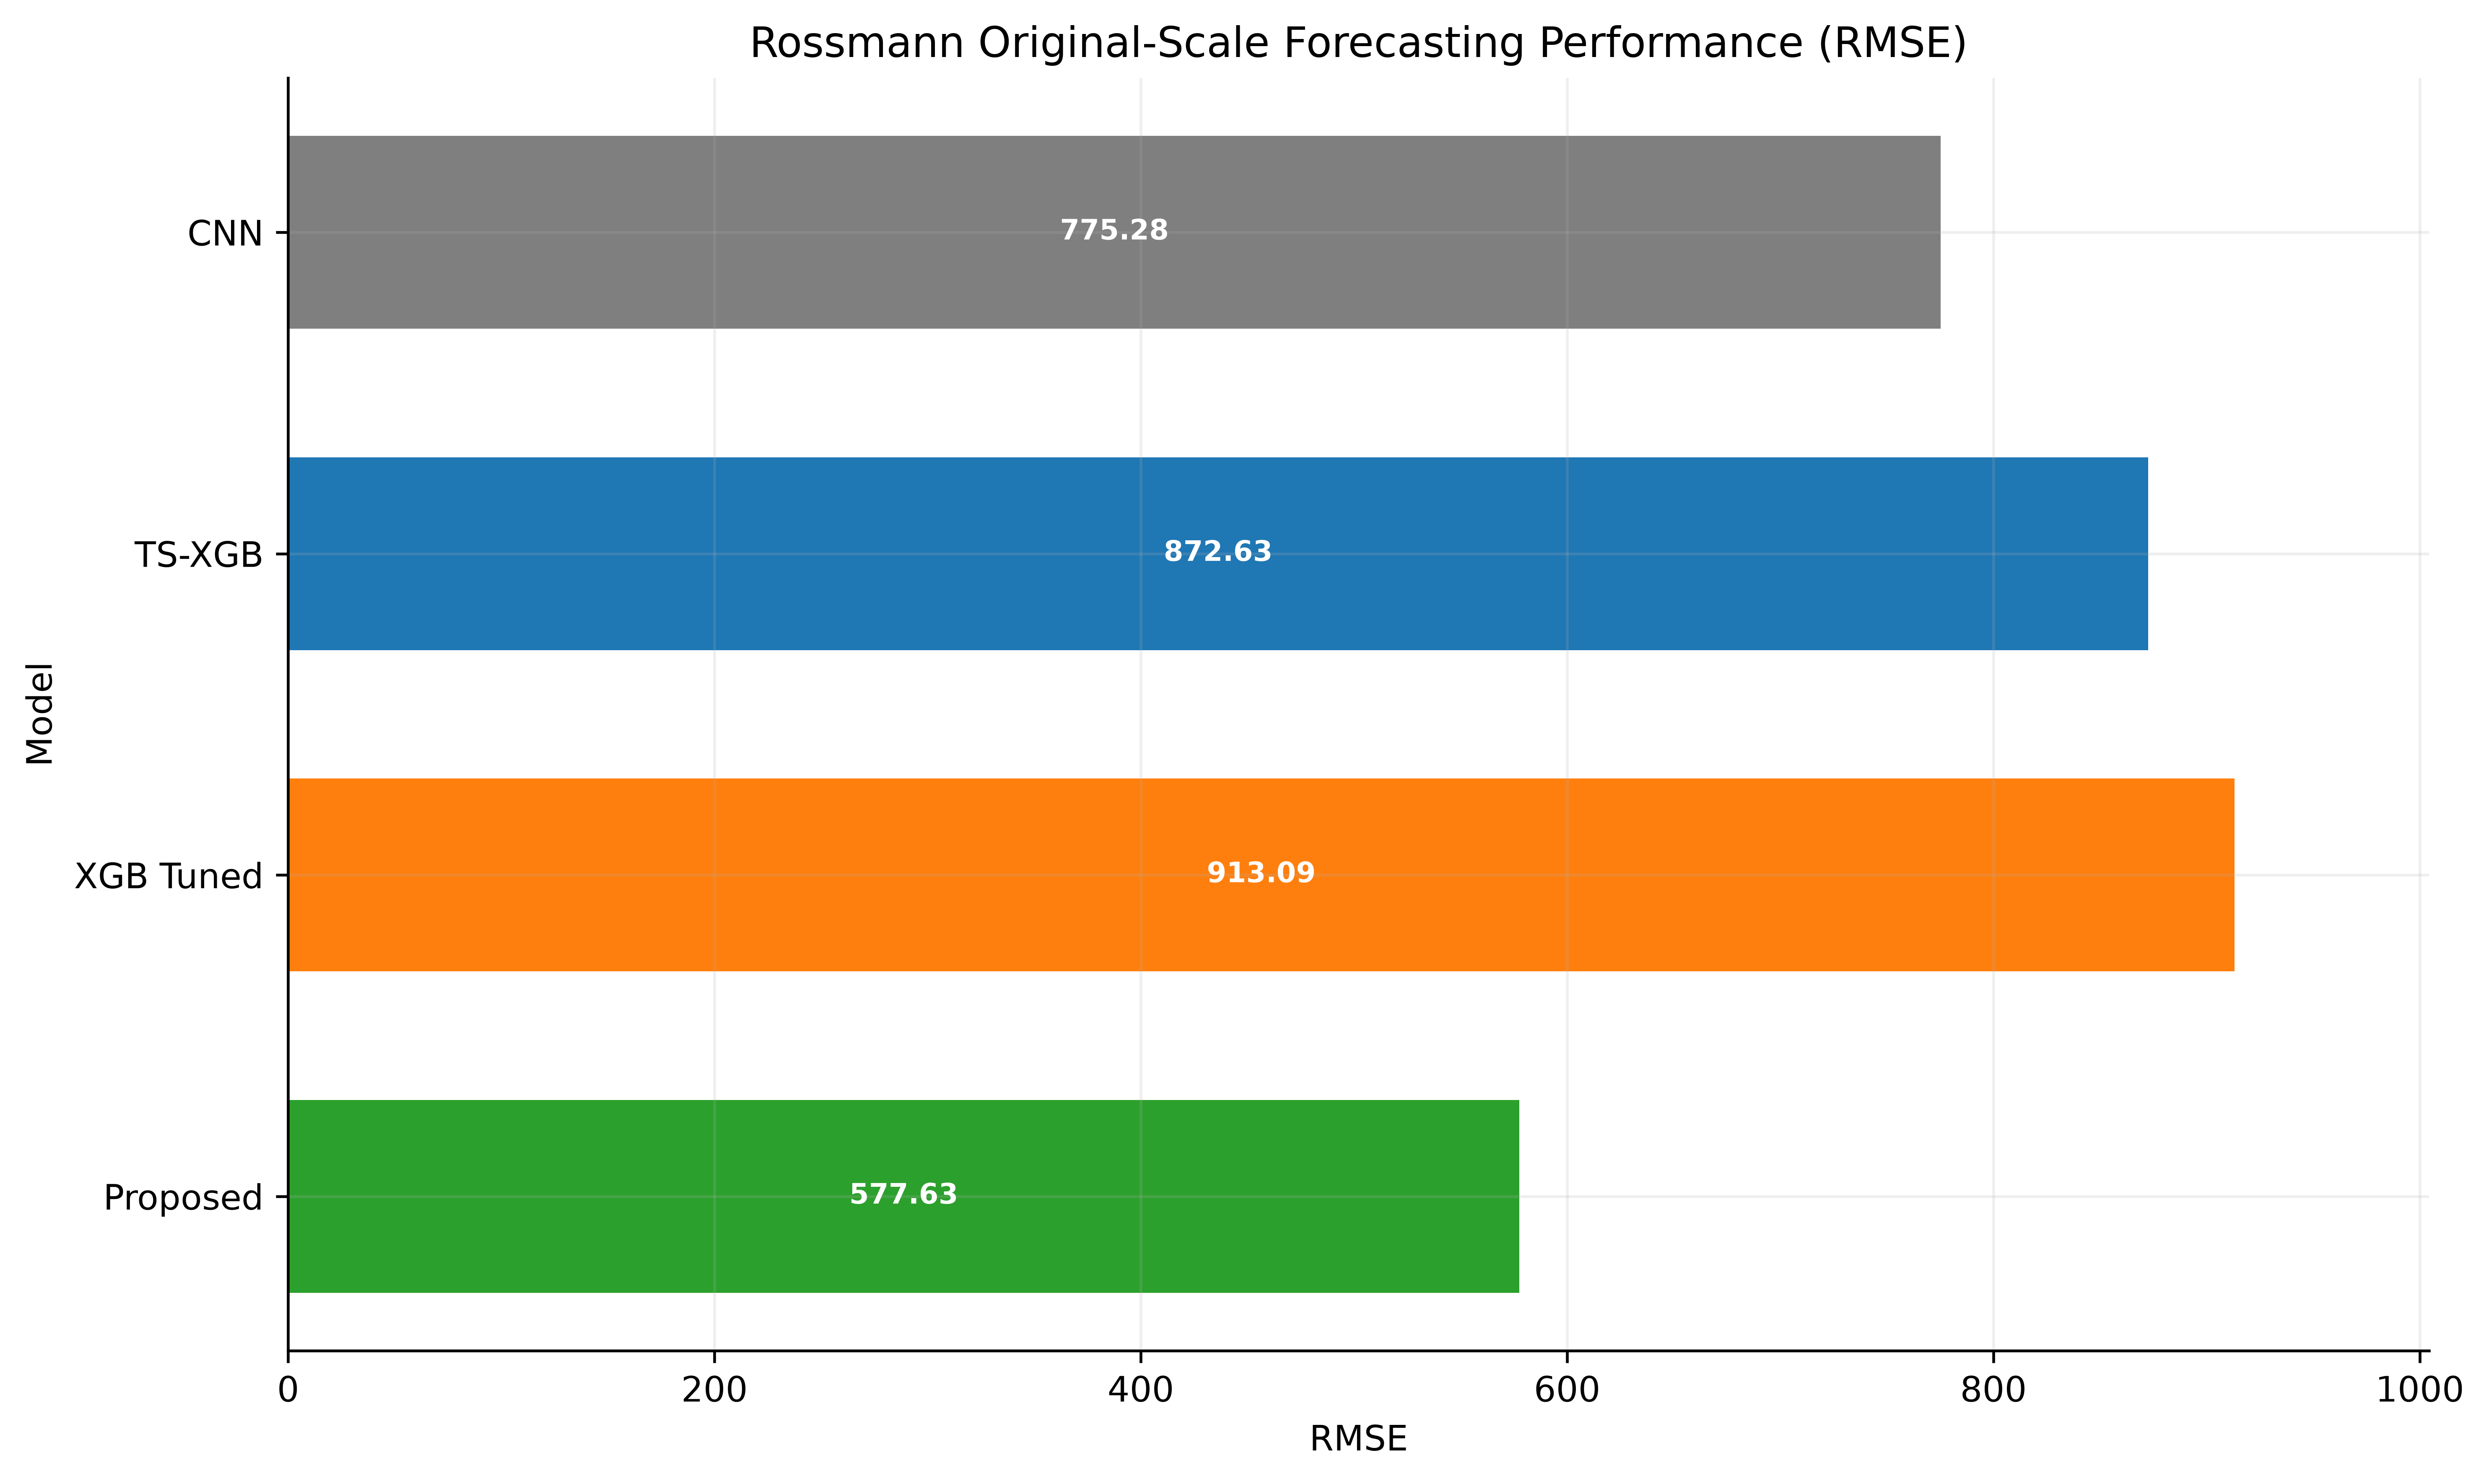

In [24]:
rossmann_original_rmse = pd.DataFrame({
    "Model": ["CNN", "TS-XGB", "XGB Tuned", "Proposed"],
    "RMSE": [775.28, 872.63, 913.09, 577.63],
})

colors = [BASELINE_COLORS[0], BASELINE_COLORS[1], BASELINE_COLORS[2], PROPOSED_COLOR]
y = np.arange(len(rossmann_original_rmse))
fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
bars = ax.barh(y, rossmann_original_rmse["RMSE"], height=0.6, color=colors)
ax.set_title("Rossmann Original-Scale Forecasting Performance (RMSE)")
ax.set_xlabel("RMSE")
ax.set_ylabel("Model")
ax.set_yticks(y)
ax.set_yticklabels(rossmann_original_rmse["Model"])
ax.set_xlim(0, rossmann_original_rmse["RMSE"].max() * 1.1)
ax.invert_yaxis()
annotate_bars(ax, fmt="{:.2f}", orientation="horizontal")
plt.tight_layout()
plt.show()


## Rossmann Log-Transformed / Scaled RMSE


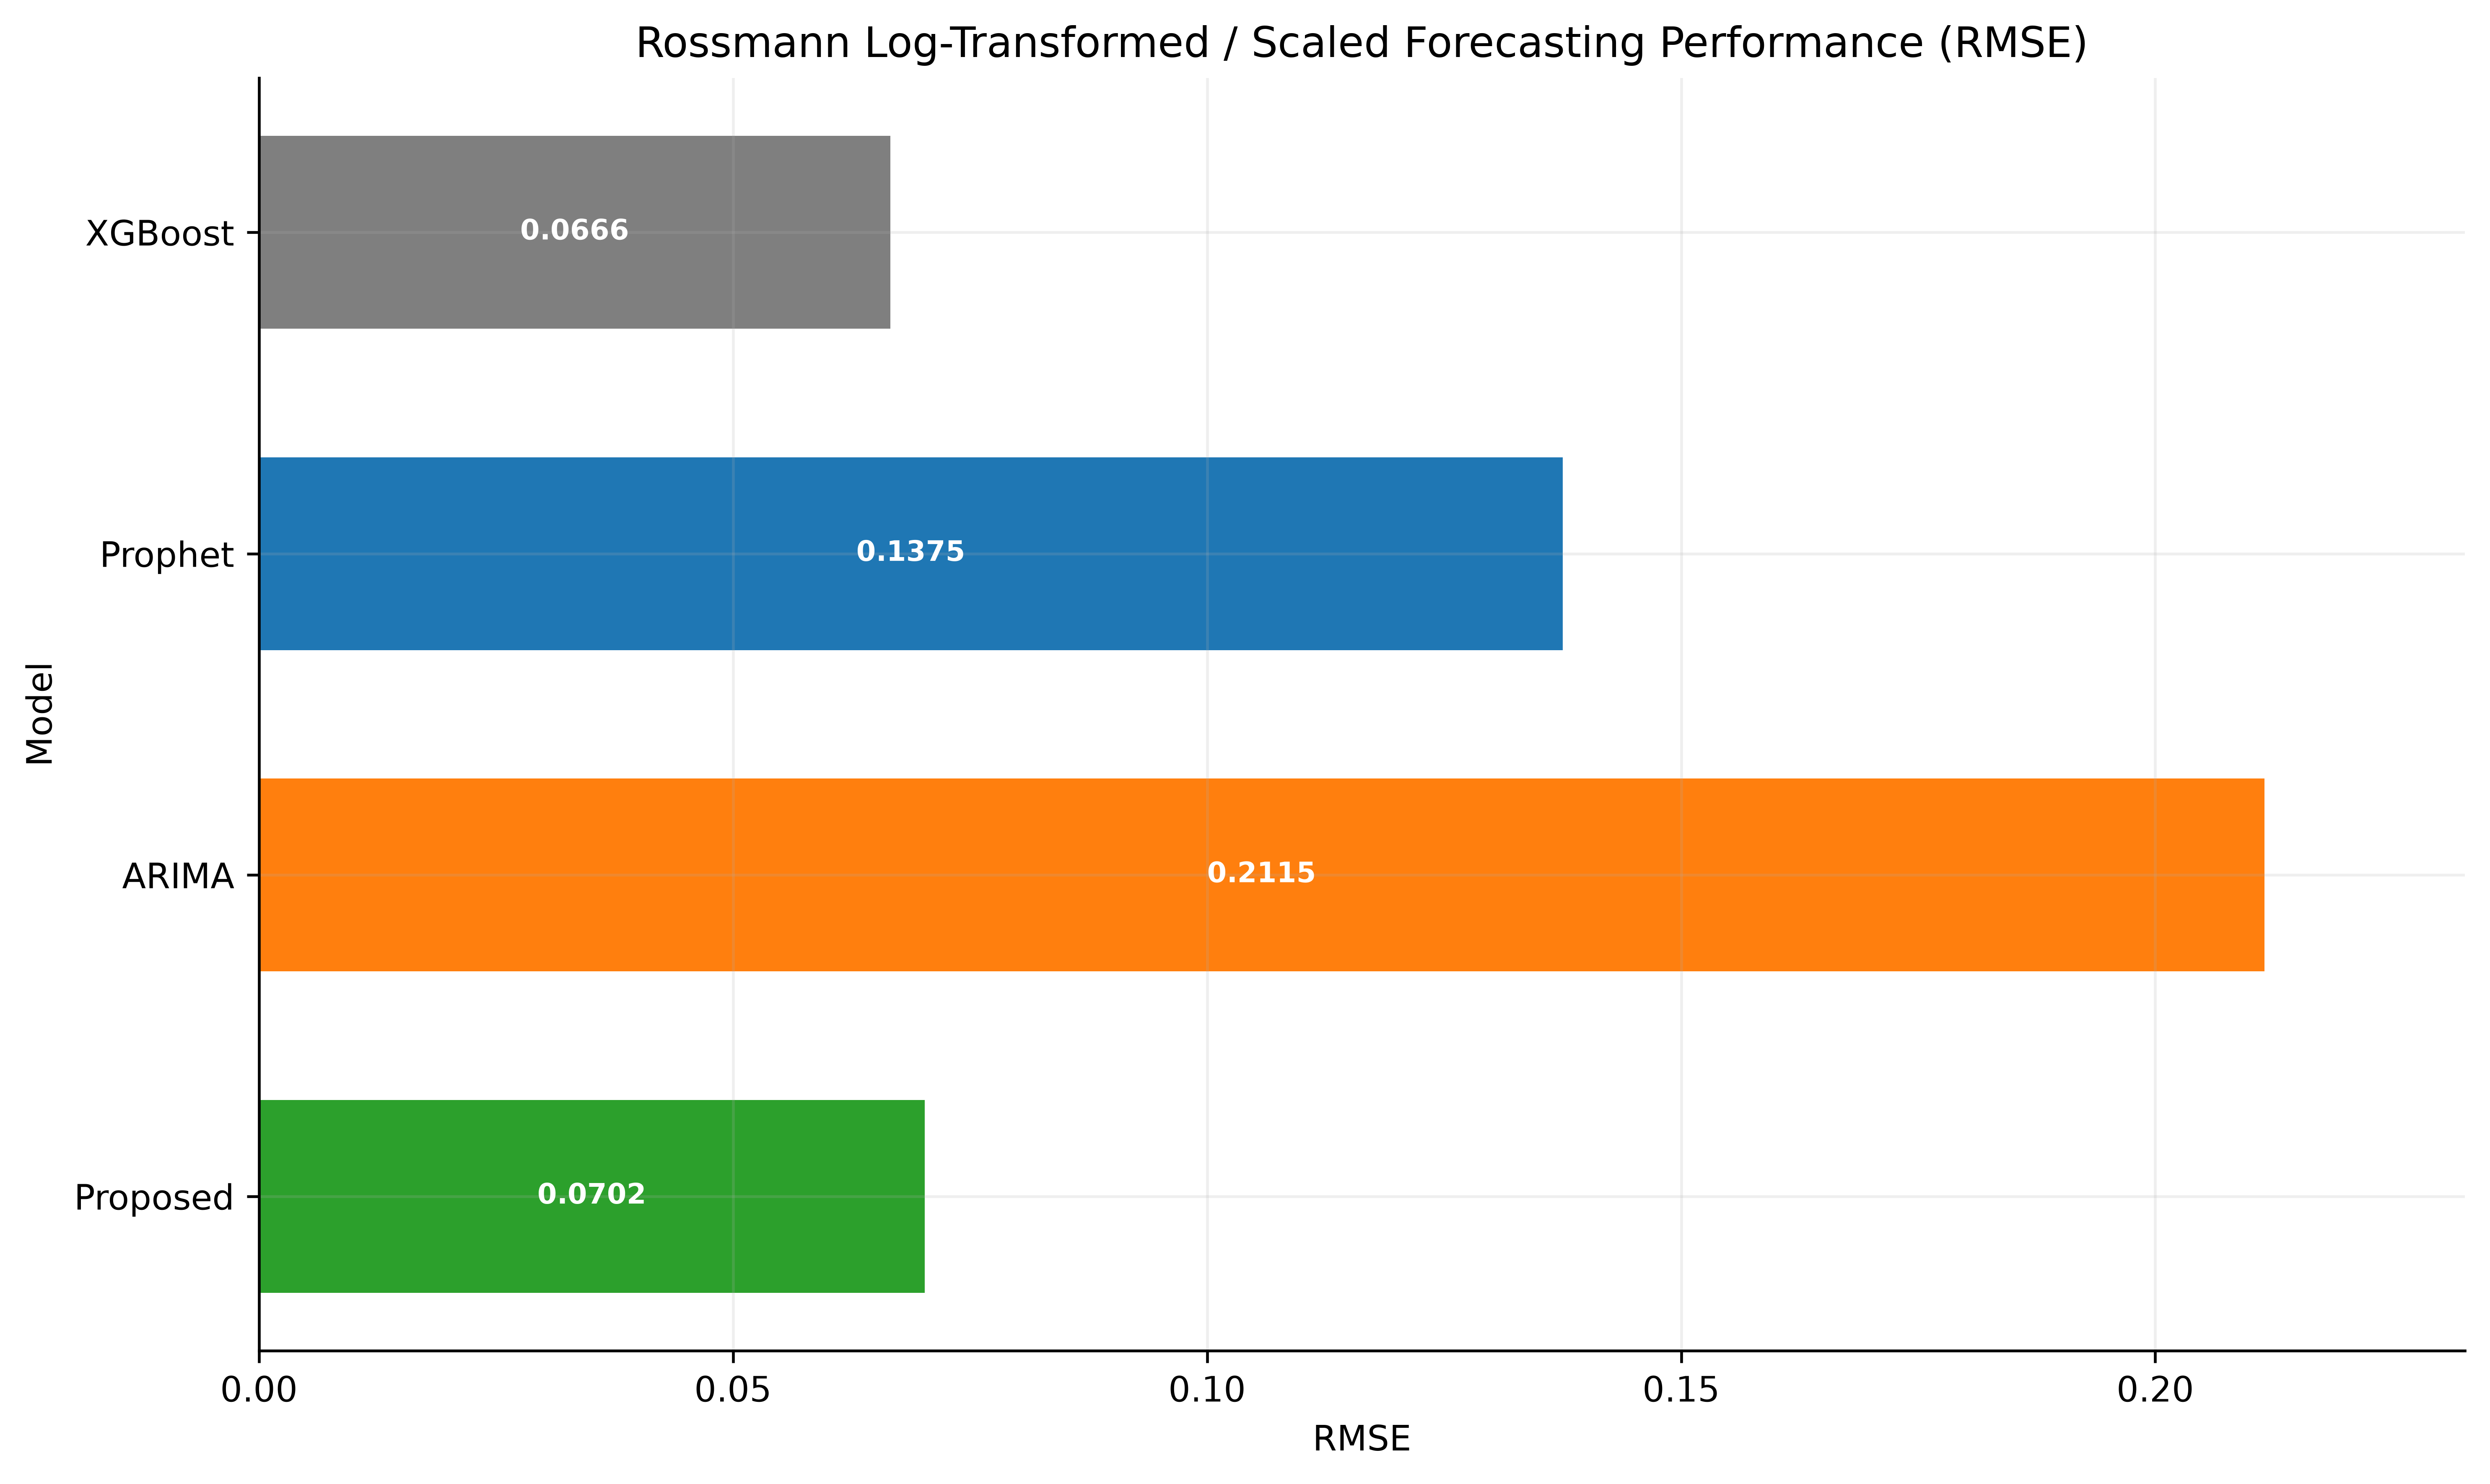

In [25]:
rossmann_scaled_rmse = pd.DataFrame({
    "Model": ["XGBoost", "Prophet", "ARIMA", "Proposed"],
    "RMSE": [0.0666, 0.1375, 0.2115, 0.07022],
})

colors = [BASELINE_COLORS[0], BASELINE_COLORS[1], BASELINE_COLORS[2], PROPOSED_COLOR]
y = np.arange(len(rossmann_scaled_rmse))
fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
bars = ax.barh(y, rossmann_scaled_rmse["RMSE"], height=0.6, color=colors)
ax.set_title("Rossmann Log-Transformed / Scaled Forecasting Performance (RMSE)")
ax.set_xlabel("RMSE")
ax.set_ylabel("Model")
ax.set_yticks(y)
ax.set_yticklabels(rossmann_scaled_rmse["Model"])
ax.set_xlim(0, rossmann_scaled_rmse["RMSE"].max() * 1.1)
ax.invert_yaxis()
annotate_bars(ax, fmt="{:.4f}", orientation="horizontal")
plt.tight_layout()
plt.show()
